In [5]:
print("Bonjour")

Bonjour


In [6]:
from pathlib import Path

DATA_DIR = Path("../data/plantvillage/source/raw/color")
print("Dataset :", DATA_DIR.resolve())
print("Existe :", DATA_DIR.exists())

Dataset : /home/kaba/formation-alternance/projet-fil-rouge/sini/data/plantvillage/source/raw/color
Existe : True


In [8]:
classes = [p.name for p in DATA_DIR.iterdir() if p.is_dir()]

print("Nombre de classes :", len(classes))
print("\nClasses :")
for classe in sorted(classes):
    print("-", classe)

Nombre de classes : 38

Classes :
- Apple___Apple_scab
- Apple___Black_rot
- Apple___Cedar_apple_rust
- Apple___healthy
- Blueberry___healthy
- Cherry_(including_sour)___Powdery_mildew
- Cherry_(including_sour)___healthy
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
- Corn_(maize)___Common_rust_
- Corn_(maize)___Northern_Leaf_Blight
- Corn_(maize)___healthy
- Grape___Black_rot
- Grape___Esca_(Black_Measles)
- Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
- Grape___healthy
- Orange___Haunglongbing_(Citrus_greening)
- Peach___Bacterial_spot
- Peach___healthy
- Pepper,_bell___Bacterial_spot
- Pepper,_bell___healthy
- Potato___Early_blight
- Potato___Late_blight
- Potato___healthy
- Raspberry___healthy
- Soybean___healthy
- Squash___Powdery_mildew
- Strawberry___Leaf_scorch
- Strawberry___healthy
- Tomato___Bacterial_spot
- Tomato___Early_blight
- Tomato___Late_blight
- Tomato___Leaf_Mold
- Tomato___Septoria_leaf_spot
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Target_Sp

In [9]:
selected_classes = [
    classe for classe in classes
    if classe.startswith("Tomato___") or classe.startswith("Corn_(maize)___")
]

print("Classes sélectionnées :", len(selected_classes))

for classe in sorted(selected_classes):
    print("-", classe)

Classes sélectionnées : 14
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
- Corn_(maize)___Common_rust_
- Corn_(maize)___Northern_Leaf_Blight
- Corn_(maize)___healthy
- Tomato___Bacterial_spot
- Tomato___Early_blight
- Tomato___Late_blight
- Tomato___Leaf_Mold
- Tomato___Septoria_leaf_spot
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Target_Spot
- Tomato___Tomato_Yellow_Leaf_Curl_Virus
- Tomato___Tomato_mosaic_virus
- Tomato___healthy


In [10]:
for classe in sorted(selected_classes):
    nb_images = len(list((DATA_DIR / classe).glob("*")))
    print(f"{classe} : {nb_images} images")

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 513 images
Corn_(maize)___Common_rust_ : 1192 images
Corn_(maize)___Northern_Leaf_Blight : 985 images
Corn_(maize)___healthy : 1162 images
Tomato___Bacterial_spot : 2127 images
Tomato___Early_blight : 1000 images
Tomato___Late_blight : 1909 images
Tomato___Leaf_Mold : 952 images
Tomato___Septoria_leaf_spot : 1771 images
Tomato___Spider_mites Two-spotted_spider_mite : 1676 images
Tomato___Target_Spot : 1404 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 5357 images
Tomato___Tomato_mosaic_virus : 373 images
Tomato___healthy : 1591 images


In [11]:
total_images = sum(
    len(list((DATA_DIR / classe).glob("*")))
    for classe in selected_classes
)

print("Total d'images sélectionnées :", total_images)

Total d'images sélectionnées : 22012


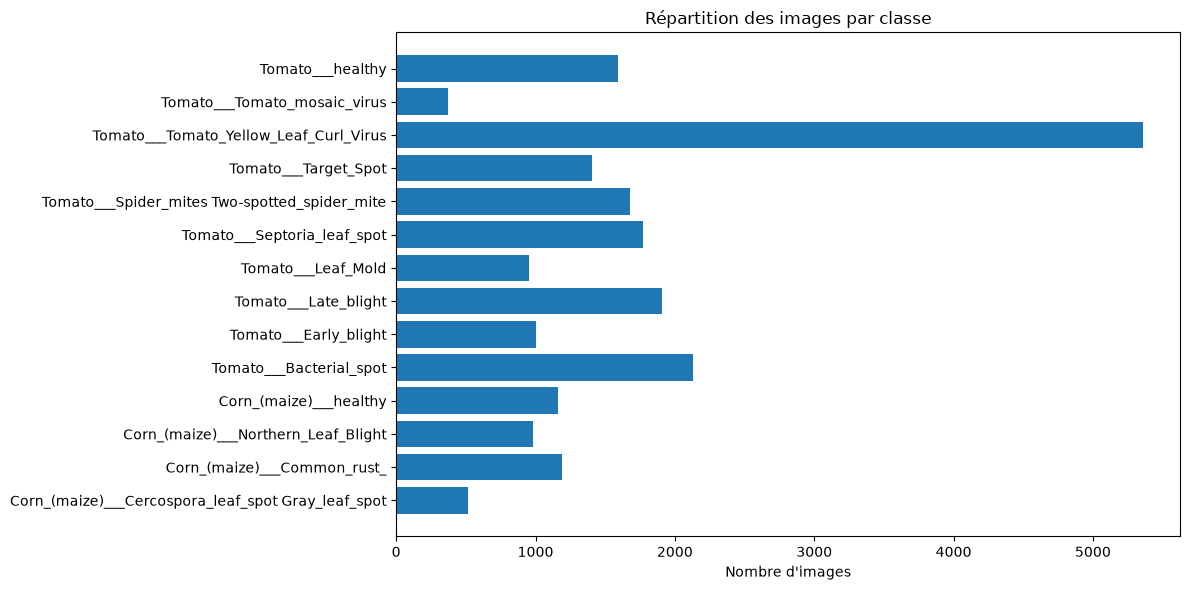

In [12]:
import matplotlib.pyplot as plt

counts = [
    len(list((DATA_DIR / classe).glob("*")))
    for classe in sorted(selected_classes)
]

plt.figure(figsize=(12, 6))
plt.barh(sorted(selected_classes), counts)
plt.xlabel("Nombre d'images")
plt.title("Répartition des images par classe")
plt.tight_layout()
plt.show()

In [13]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

print("Transformations prêtes.")

Transformations prêtes.


In [14]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

print("Nombre total d'images :", len(dataset))
print("Nombre de classes :", len(dataset.classes))

Nombre total d'images : 54305
Nombre de classes : 38


In [15]:
from torch.utils.data import Subset

selected_indices = [
    i for i, (_, label) in enumerate(dataset.samples)
    if dataset.classes[label] in selected_classes
]

filtered_dataset = Subset(dataset, selected_indices)

print("Nombre d'images filtrées :", len(filtered_dataset))

Nombre d'images filtrées : 22012


In [16]:
from torch.utils.data import random_split

train_size = int(0.8 * len(filtered_dataset))
test_size = len(filtered_dataset) - train_size

train_dataset, test_dataset = random_split(
    filtered_dataset,
    [train_size, test_size]
)

print("Images entraînement :", len(train_dataset))
print("Images test :", len(test_dataset))

Images entraînement : 17609
Images test : 4403


In [17]:
print("Classes :", dataset.classes)

print("\nNombre de classes sélectionnées :", len(selected_classes))
print("Images d'entraînement :", len(train_dataset))
print("Images de test :", len(test_dataset))

Classes : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato__